IMPORTING LIBRARIES


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import ( accuracy_score,
                             precision_score,
                              f1_score,
                              confusion_matrix,
                              classification_report,
                              recall_score)


In [3]:
df=pd.read_csv("neo.csv")

LOADING DATASET

In [4]:
df

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True
...,...,...,...,...,...,...,...,...,...,...
90831,3763337,(2016 VX1),0.026580,0.059435,52078.886692,1.230039e+07,Earth,False,25.00,False
90832,3837603,(2019 AD3),0.016771,0.037501,46114.605073,5.432121e+07,Earth,False,26.00,False
90833,54017201,(2020 JP3),0.031956,0.071456,7566.807732,2.840077e+07,Earth,False,24.60,False
90834,54115824,(2021 CN5),0.007321,0.016370,69199.154484,6.869206e+07,Earth,False,27.80,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


In [6]:
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [7]:
df.tail()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
90831,3763337,(2016 VX1),0.026580,0.059435,52078.886692,1.230039e+07,Earth,False,25.00,False
90832,3837603,(2019 AD3),0.016771,0.037501,46114.605073,5.432121e+07,Earth,False,26.00,False
90833,54017201,(2020 JP3),0.031956,0.071456,7566.807732,2.840077e+07,Earth,False,24.60,False
90834,54115824,(2021 CN5),0.007321,0.016370,69199.154484,6.869206e+07,Earth,False,27.80,False
90835,54205447,(2021 TW7),0.039862,0.089133,27024.455553,5.977213e+07,Earth,False,24.12,False


In [8]:
df.isnull()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
90831,False,False,False,False,False,False,False,False,False,False
90832,False,False,False,False,False,False,False,False,False,False
90833,False,False,False,False,False,False,False,False,False,False
90834,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

,0
id,0
name,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
orbiting_body,0
sentry_object,0
absolute_magnitude,0
hazardous,0


In [10]:
df.shape #90836 rows and 10 columns

(90836, 10)

In [11]:
df.describe()

,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,9.083600e+04,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,1.438288e+07,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,2.087202e+07,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,2.000433e+06,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,3.448110e+06,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,3.748362e+06,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,3.884023e+06,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,5.427591e+07,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


In [12]:
df.duplicated().sum()

np.int64(0)

UNDERSTANDING THE TARGET

0=Not Potentially Hazardous
1=Potentially Hazardous

In [13]:
df["hazardous"].value_counts()

,count
hazardous,
False,81996
True,8840


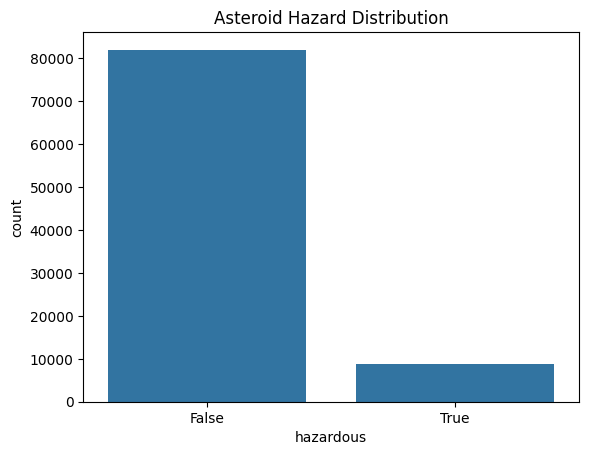

In [14]:
sns.countplot(x="hazardous",data=df)
plt.title("Asteroid Hazard Distribution")
plt.show()

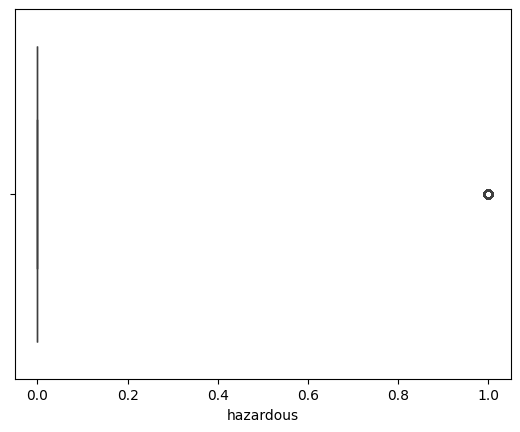

In [15]:
sns.boxplot(x="hazardous",data=df)
plt.show()

REMOVING UNNECESSARY COLUMNS

In [16]:
columns_to_drop=["id","name"]
df=df.drop(columns=columns_to_drop,errors="ignore")

In [17]:
df

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True
...,...,...,...,...,...,...,...,...
90831,0.026580,0.059435,52078.886692,1.230039e+07,Earth,False,25.00,False
90832,0.016771,0.037501,46114.605073,5.432121e+07,Earth,False,26.00,False
90833,0.031956,0.071456,7566.807732,2.840077e+07,Earth,False,24.60,False
90834,0.007321,0.016370,69199.154484,6.869206e+07,Earth,False,27.80,False


EXPLORATORY ANALYSIS

Diameter Distribution

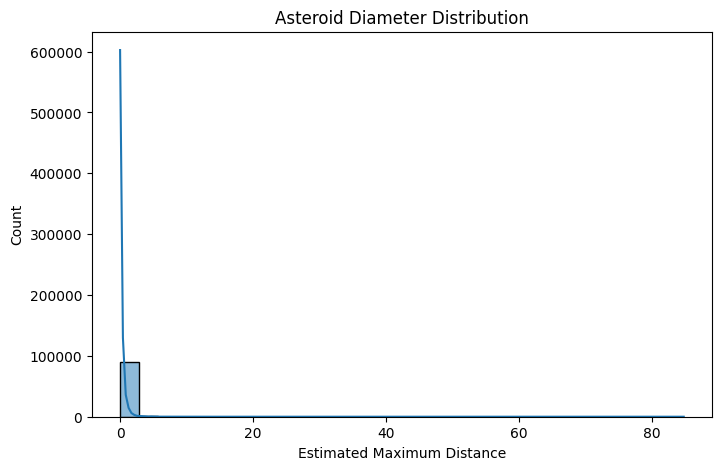

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["est_diameter_max"],bins=30,kde=True)
plt.title("Asteroid Diameter Distribution")
plt.xlabel("Estimated Maximum Distance")
plt.show()

RELATIVE VELOCITY

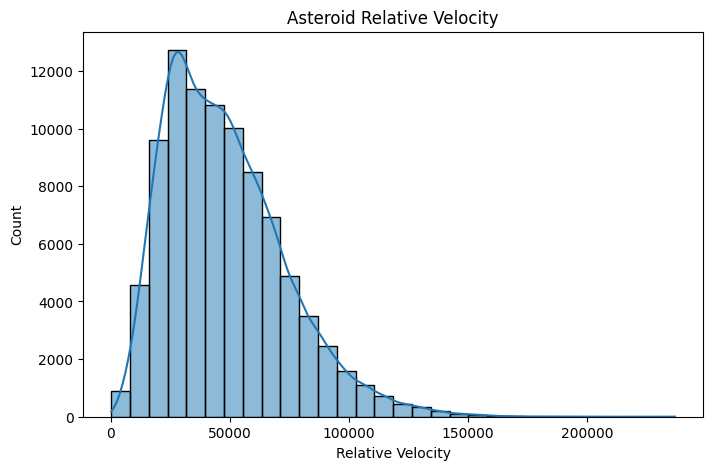

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["relative_velocity"],bins=30,kde=True)
plt.title('Asteroid Relative Velocity')
plt.xlabel("Relative Velocity")
plt.show()



MISS DISTANCE

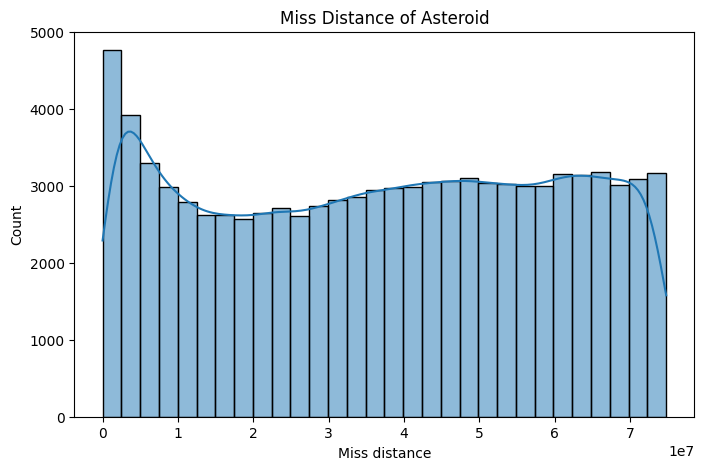

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df["miss_distance"],bins=30,kde=True)
plt.title("Miss Distance of Asteroid")
plt.xlabel("Miss distance")
plt.show()

CORRELATION ANALYSIS

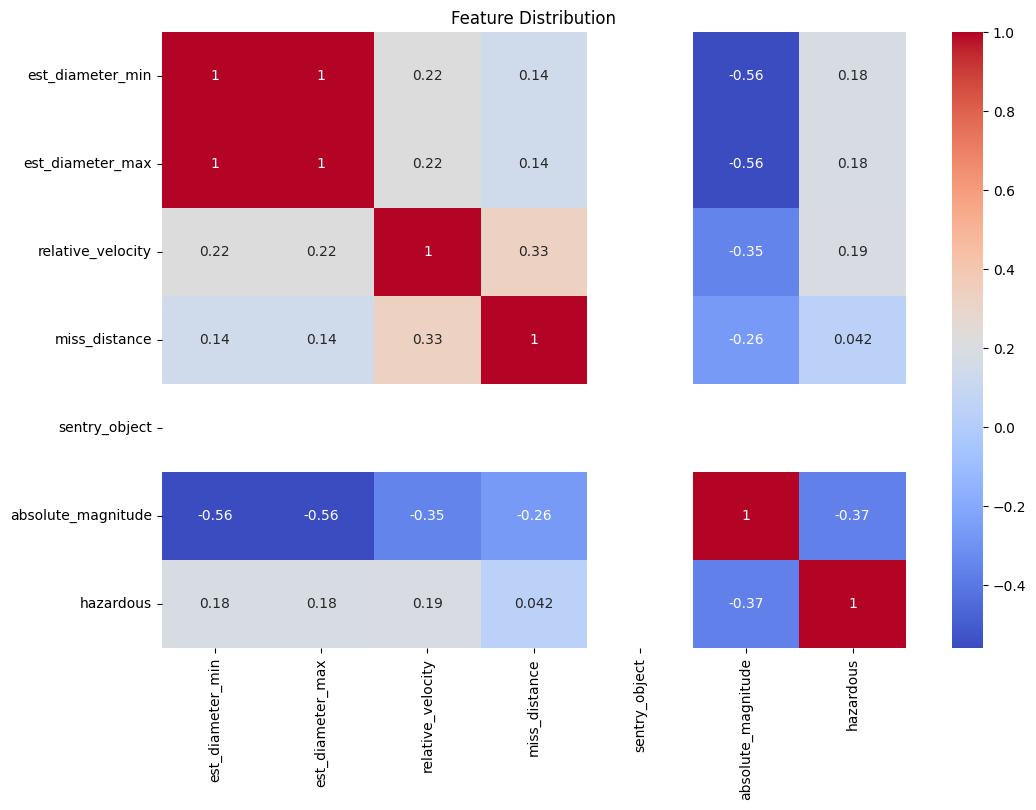

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm",annot=True)
plt.title("Feature Distribution")
plt.show()

FEATURE SELECTION

In [22]:
features=["est_diameter_min","est_diameter_min","relative_velocity","miss_distance","orbiting_body","sentry_object","absolute_magnitude"]

x=df[features]
y=df["hazardous"]

In [23]:
x.head()

,est_diameter_min,est_diameter_min,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude
0,1.198271,1.198271,13569.249224,5.483974e+07,Earth,False,16.73
1,0.265800,0.265800,73588.726663,6.143813e+07,Earth,False,20.00
2,0.722030,0.722030,114258.692129,4.979872e+07,Earth,False,17.83
3,0.096506,0.096506,24764.303138,2.543497e+07,Earth,False,22.20
4,0.255009,0.255009,42737.733765,4.627557e+07,Earth,False,20.09


In [24]:
x.tail()

,est_diameter_min,est_diameter_min,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude
90831,0.026580,0.026580,52078.886692,1.230039e+07,Earth,False,25.00
90832,0.016771,0.016771,46114.605073,5.432121e+07,Earth,False,26.00
90833,0.031956,0.031956,7566.807732,2.840077e+07,Earth,False,24.60
90834,0.007321,0.007321,69199.154484,6.869206e+07,Earth,False,27.80
90835,0.039862,0.039862,27024.455553,5.977213e+07,Earth,False,24.12


FEATURE SCALING

The orbiting body and sentry object is in string so we have to convert it into numerical values

In [25]:
scaler = StandardScaler()

# Correct the features list to include all intended features and remove duplicates
# Assuming 'est_diameter_max' was intended instead of the second 'est_diameter_min'
corrected_features = ["est_diameter_min", "est_diameter_max", "relative_velocity",
                      "miss_distance", "orbiting_body", "sentry_object", "absolute_magnitude"]

# Recreate x and y using the corrected features from the original dataframe 'df'
x = df[corrected_features]
y = df["hazardous"]

# Perform train-test split again with the corrected x and y
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


# Convert boolean column 'sentry_object' to int
x_train['sentry_object'] = x_train['sentry_object'].astype(int)
x_test['sentry_object'] = x_test['sentry_object'].astype(int)

# One-hot encode 'orbiting_body'
# Now 'orbiting_body' should be present
x_train = pd.get_dummies(x_train, columns=['orbiting_body'], drop_first=True)
x_test = pd.get_dummies(x_test, columns=['orbiting_body'], drop_first=True)

# Align columns between x_train and x_test after one-hot encoding
all_columns = list(set(x_train.columns) | set(x_test.columns))

# Reindex both dataframes to have the complete set of columns, filling missing with 0
x_train = x_train.reindex(columns=all_columns, fill_value=0)
x_test = x_test.reindex(columns=all_columns, fill_value=0)

# Ensure the order of columns is identical for both train and test sets before scaling
x_train = x_train.sort_index(axis=1)
x_test = x_test.sort_index(axis=1)

# Apply scaling
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

FEATURE SCALING

In [26]:
# Correct the features list to include all intended features and remove duplicates
corrected_features = ["est_diameter_min", "est_diameter_max", "relative_velocity",
                      "miss_distance", "orbiting_body", "sentry_object", "absolute_magnitude"]

# Recreate x and y using the corrected features from the original dataframe 'df'
x = df[corrected_features]
y = df["hazardous"]

# Perform train-test split again with the corrected x and y
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Convert boolean column 'sentry_object' to int
x_train['sentry_object'] = x_train['sentry_object'].astype(int)
x_test['sentry_object'] = x_test['sentry_object'].astype(int)

# One-hot encode 'orbiting_body'
x_train = pd.get_dummies(x_train, columns=['orbiting_body'], drop_first=True)
x_test = pd.get_dummies(x_test, columns=['orbiting_body'], drop_first=True)

# Align columns between x_train and x_test after one-hot encoding
# Create a union of all columns present in both train and test sets
all_columns = list(set(x_train.columns) | set(x_test.columns))

# Reindex both dataframes to have the complete set of columns, filling missing with 0
x_train = x_train.reindex(columns=all_columns, fill_value=0)
x_test = x_test.reindex(columns=all_columns, fill_value=0)

# Ensure the order of columns is identical for both train and test sets before scaling
x_train = x_train.sort_index(axis=1)
x_test = x_test.sort_index(axis=1)

# Apply scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

TRAIN TEST SPLIT

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

MODEL 1-LOGISTIC REGRESSION

In [28]:
log_model=LogisticRegression(max_iter=100)
log_model.fit(x_train_scaled,y_train)
y_pred_lr=log_model.predict(x_test_scaled)
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

       False       0.91      0.99      0.95     16400
        True       0.52      0.08      0.14      1768

    accuracy                           0.90     18168
   macro avg       0.71      0.54      0.54     18168
weighted avg       0.87      0.90      0.87     18168



MODEL2-DECISION TREE

In [29]:
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train_scaled,y_train)
y_pred_dt=dt_model.predict(x_test_scaled)
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

       False       0.94      0.94      0.94     16400
        True       0.43      0.45      0.44      1768

    accuracy                           0.89     18168
   macro avg       0.69      0.69      0.69     18168
weighted avg       0.89      0.89      0.89     18168



MODEL 3 - RANDOM FOREST

In [30]:
rf_model=RandomForestClassifier(n_estimators=200,random_state=42)
rf_model.fit(x_train_scaled,y_train)
y_pred_rf=rf_model.predict(x_test_scaled)
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

       False       0.94      0.97      0.95     16400
        True       0.61      0.42      0.50      1768

    accuracy                           0.92     18168
   macro avg       0.77      0.70      0.73     18168
weighted avg       0.91      0.92      0.91     18168



Gradient Boosting

In [31]:
gb_model=GradientBoostingClassifier(n_estimators=100,random_state=42,learning_rate=0.1)
gb_model.fit(x_train_scaled,y_train)
y_pred_gb=gb_model.predict(x_test_scaled)
print(classification_report(y_test,y_pred_gb))

              precision    recall  f1-score   support

       False       0.92      1.00      0.95     16400
        True       0.84      0.15      0.26      1768

    accuracy                           0.91     18168
   macro avg       0.88      0.57      0.61     18168
weighted avg       0.91      0.91      0.89     18168



XGBOOSTING

In [33]:
xg_model=XGBClassifier(
    n_estimators=100,
    random_state=42,
    learning_rate=0.05,
    max_depth=5,
    eval_metric="logloss"

)

xg_model.fit(x_train_scaled,y_train)
y_pred_xg=xg_model.predict(x_test_scaled)
print(classification_report(y_test,y_pred_xg))

              precision    recall  f1-score   support

       False       0.92      1.00      0.95     16400
        True       0.82      0.15      0.26      1768

    accuracy                           0.91     18168
   macro avg       0.87      0.57      0.61     18168
weighted avg       0.91      0.91      0.89     18168



COMPARING ALL THE MODELS


In [34]:
def evaluate_model (name,y_true,y_pred):

  return{
      "model":name,
      "Accuracy":accuracy_score(y_true,y_pred),
      "precision":precision_score(y_true,y_pred),
      "recall":recall_score(y_true,y_pred),
      "F1-Score":f1_score(y_true,y_pred)
  }

In [36]:
results=[]

results.append(
    evaluate_model("Logistic Regression",y_test,y_pred_lr)
)
results.append(evaluate_model("Decision Tree",y_test,y_pred_dt))
results.append(evaluate_model("Random Forest",y_test,y_pred_rf))
results.append(evaluate_model("Gradient Boosting",y_test,y_pred_gb))
results.append(evaluate_model("XGBoosting",y_test,y_pred_xg))


In [37]:
results_df=pd.DataFrame(results)
results_df

,model,Accuracy,precision,recall,F1-Score
0,Logistic Regression,0.903292,0.520755,0.078054,0.135760
1,Decision Tree,0.889366,0.433735,0.447964,0.440735
2,Random Forest,0.917327,0.608660,0.421380,0.497995
3,Gradient Boosting,0.914740,0.841121,0.152715,0.258497
4,XGBoosting,0.914190,0.819572,0.151584,0.255847


In [38]:
results_df.sort_values(by="F1-Score",ascending=False)

,model,Accuracy,precision,recall,F1-Score
2,Random Forest,0.917327,0.608660,0.421380,0.497995
1,Decision Tree,0.889366,0.433735,0.447964,0.440735
3,Gradient Boosting,0.914740,0.841121,0.152715,0.258497
4,XGBoosting,0.914190,0.819572,0.151584,0.255847
0,Logistic Regression,0.903292,0.520755,0.078054,0.135760


CONFUSION MATRIX(for the best model)

In [39]:
cm=confusion_matrix(y_test,y_pred_rf)


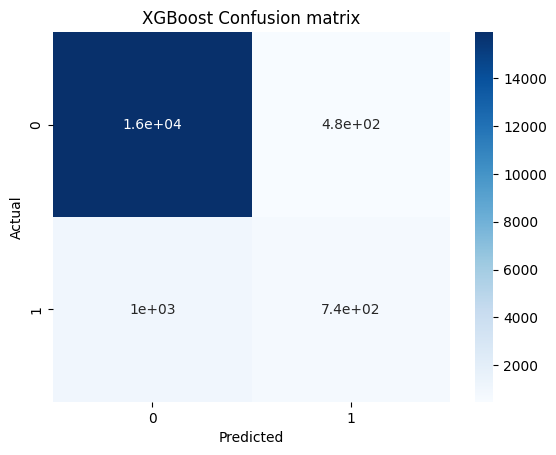

In [40]:
sns.heatmap(cm,annot=True,cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion matrix")
plt.show()

FEATURE IMPORTANCE

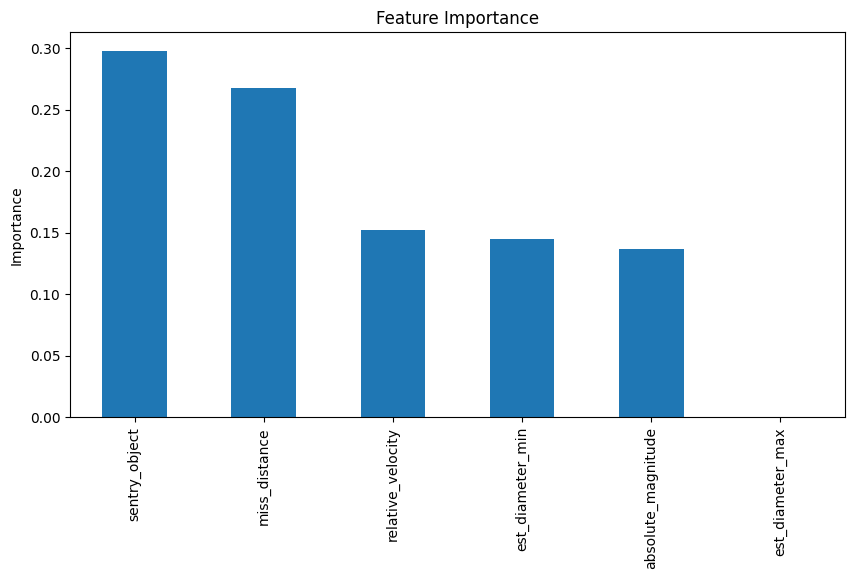

In [41]:
#Using Random Forest

importance=pd.Series(rf_model.feature_importances_,index=all_columns)
importance=importance.sort_values(ascending=False)
importance.plot(kind="bar",figsize=(10,5))
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

CROSS VALIDATION

In [ ]:
# Create a copy of x to apply transformations for cross-validation
x_for_cv = x.copy()

# Convert 'sentry_object' from boolean to integer
x_for_cv['sentry_object'] = x_for_cv['sentry_object'].astype(int)

# One-hot encode 'orbiting_body'.
# The original preprocessing used drop_first=True. If 'Earth' is the only value,
# this will effectively drop the column without adding new ones for it.
x_for_cv = pd.get_dummies(x_for_cv, columns=['orbiting_body'], drop_first=True)

# Ensure columns of x_for_cv match the columns used during model training (`all_columns`)
x_for_cv = x_for_cv.reindex(columns=all_columns, fill_value=0)

# Sort columns to ensure consistent order
x_for_cv = x_for_cv.sort_index(axis=1)

# Apply the same scaling as applied to the training data (scaler was fitted on x_train)
x_for_cv_scaled = scaler.transform(x_for_cv)

cv_scores=cross_val_score(rf_model,x_for_cv_scaled,y,cv=5,scoring="f1")
print("CV Scores:",cv_scores)
print("Mean F1:",cv_scores.mean())

HYPERPARAMETER TUNING(improving Random Forest)

In [ ]:
param_grid={
    "n_estimators":[100,200,300],
    "max_depth":[None,10,20],
    "min_sample_split":[2,5]
}

In [ ]:
grid_search=GridSearchCV(RandomForestClassifier(random_state=42),param_grid,cv=5,scoring="f1",n_jobs=-1)

In [ ]:
param_grid={
    "n_estimators":[100,200,300],
    "max_depth":[None,10,20],
    "min_samples_split":[2,5] # Corrected parameter name
}

grid_search=GridSearchCV(RandomForestClassifier(random_state=42),param_grid,cv=5,scoring="f1",n_jobs=-1)

grid_search.fit(x_train_scaled,y_train)

In [ ]:
print(grid_search.best_params_)

In [ ]:
best_model=grid_search.best_estimator_

In [ ]:
best_predictions=best_model.predict(x_train_scaled)

In [ ]:
best_predictions=best_model.predict(x_test_scaled)
print(classification_report(y_test,best_predictions))